# Exercise Sheet 3 – CARLA Baseline Models
**Introduction to Machine Learning Safety**

Covers Ex 3.4 (Dataset Exploration) · 3.5 (Train Classifiers) · 3.6 (Evaluation) · 3.7 (ODD Gap Analysis)

> **Dataset structure assumed:**
> ```
> CARLA_DATASET/
>   train/
>     rgb-front/      ← 000000.jpg, 000010.jpg, …
>     labels.feather  ← frame, has_pedestrian, has_traffic_light, has_vehicle
>   test/
>     rgb-front/
>     labels.feather
> ```


## 0. Setup

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")


CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Config — set your Drive path here

In [ ]:
from pathlib import Path
import torch

# ✏️ Edit this to match your Google Drive folder name
DATA_ROOT = Path("/content/drive/MyDrive/CARLA_DATASET")

SAVE_DIR    = Path("/content/saved_models")
RESULTS_DIR = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

LABEL_NAMES  = ["pedestrian", "traffic_light", "vehicle"]
LABEL_COLS   = ["has_pedestrian", "has_traffic_light", "has_vehicle"]  # feather column names

BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 1e-4
VAL_FRAC     = 0.15
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## Imports

In [ ]:
import os, json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.notebook import tqdm

print("All imports OK ✓")


All imports OK ✓


## Dataset class & Transforms

In [ ]:
class CarlaDataset(Dataset):
    """
    Loads rgb-front images matched to labels.feather by frame number.
    Image filenames: {frame:06d}.jpg  e.g. frame=0 -> 000000.jpg
    Labels: has_pedestrian, has_traffic_light, has_vehicle (bool -> 0/1)
    """
    def __init__(self, root: Path, transform=None):
        self.root      = root
        self.img_dir   = root / "rgb-front"
        self.transform = transform

        df = pd.read_feather(root / "labels.feather")
        # Keep only rows where the image file actually exists
        records = []
        for _, row in df.iterrows():
            fname = f"{int(row['frame']):06d}.jpg"
            if (self.img_dir / fname).exists():
                records.append({
                    "fname":         fname,
                    "pedestrian":    int(row["has_pedestrian"]),
                    "traffic_light": int(row["has_traffic_light"]),
                    "vehicle":       int(row["has_vehicle"]),
                })
        self.samples = records
        print(f"  Loaded {len(self.samples)} samples from {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(self.img_dir / s["fname"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(
            [s["pedestrian"], s["traffic_light"], s["vehicle"]],
            dtype=torch.float32)
        return img, label


# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print("Dataset class and transforms defined ✓")


Dataset class and transforms defined ✓


## Exercise 3.4 – Dataset Exploration
1. How many images in train / test?
2. Class distribution — balanced?
3. Example images per label combination


In [ ]:
def explore_dataset():
    train_ds = CarlaDataset(DATA_ROOT / "train", transform=eval_transform)
    test_ds  = CarlaDataset(DATA_ROOT / "test",  transform=eval_transform)

    print(f"\nTraining images : {len(train_ds)}")
    print(f"Test images     : {len(test_ds)}")

    for split_name, ds in [("train", train_ds), ("test", test_ds)]:
        print(f"\nClass distribution ({split_name}):")
        for col in ["pedestrian", "traffic_light", "vehicle"]:
            pos   = sum(s[col] for s in ds.samples)
            neg   = len(ds) - pos
            rate  = pos / len(ds) * 100
            flag  = "✓ balanced" if 30 <= rate <= 70 else "✗ IMBALANCED"
            print(f"  {col:<15}  pos={pos:>5}  neg={neg:>5}  "
                  f"pos_rate={rate:5.1f}%  {flag}")
    return train_ds, test_ds


train_ds, test_ds = explore_dataset()


  Loaded 7200 samples from /content/drive/MyDrive/CARLA_DATASET/train
  Loaded 3600 samples from /content/drive/MyDrive/CARLA_DATASET/test

Training images : 7200
Test images     : 3600

Class distribution (train):
  pedestrian       pos= 1718  neg= 5482  pos_rate= 23.9%  ✗ IMBALANCED
  traffic_light    pos= 5276  neg= 1924  pos_rate= 73.3%  ✗ IMBALANCED
  vehicle          pos= 5458  neg= 1742  pos_rate= 75.8%  ✗ IMBALANCED

Class distribution (test):
  pedestrian       pos=  706  neg= 2894  pos_rate= 19.6%  ✗ IMBALANCED
  traffic_light    pos= 2584  neg= 1016  pos_rate= 71.8%  ✗ IMBALANCED
  vehicle          pos= 2700  neg=  900  pos_rate= 75.0%  ✗ IMBALANCED


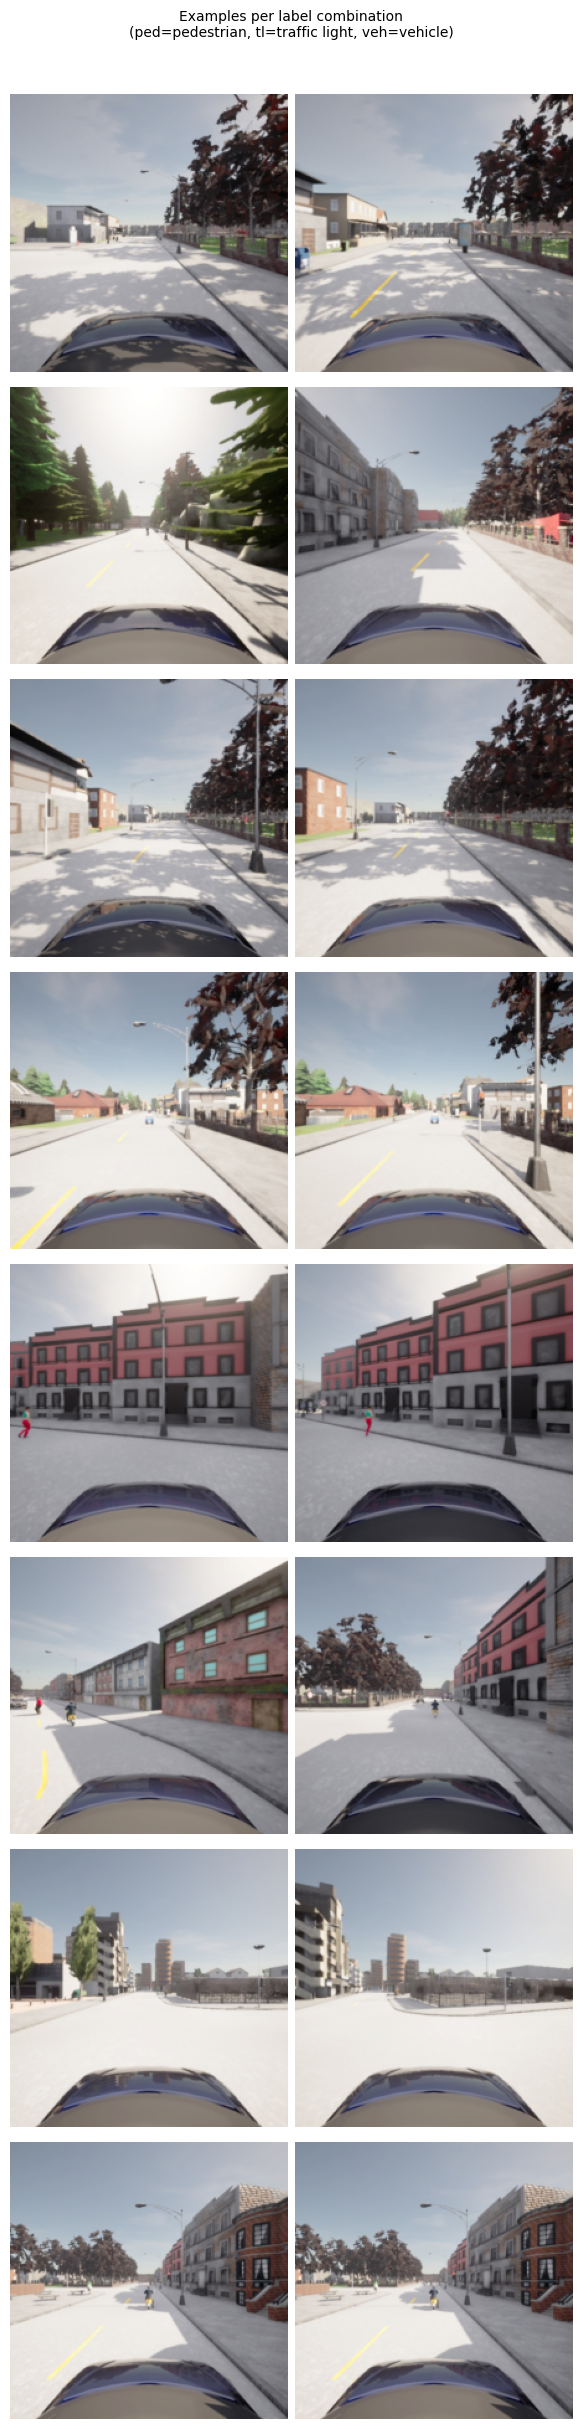

Saved → results/dataset_examples.png


In [ ]:
def show_examples(dataset, n_per_combo=2):
    """Grid of images grouped by (pedestrian, traffic_light, vehicle) label combo."""
    combos = {}
    for idx, s in enumerate(dataset.samples):
        key = (s["pedestrian"], s["traffic_light"], s["vehicle"])
        combos.setdefault(key, []).append(idx)

    inv = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std =[1/0.229, 1/0.224, 1/0.225])

    n = len(combos)
    fig, axes = plt.subplots(n, n_per_combo, figsize=(n_per_combo*3, n*3))
    if n == 1: axes = axes[None, :]

    for row, (combo, idxs) in enumerate(sorted(combos.items())):
        lbl = f"ped={combo[0]} tl={combo[1]} veh={combo[2]}"
        for col in range(n_per_combo):
            ax = axes[row, col]
            if col < len(idxs):
                img, _ = dataset[idxs[col]]
                img = inv(img).clamp(0,1).permute(1,2,0).numpy()
                ax.imshow(img)
                if col == 0:
                    ax.set_ylabel(lbl, fontsize=8)
            ax.axis("off")

    plt.suptitle("Examples per label combination\n(ped=pedestrian, tl=traffic light, veh=vehicle)",
                 fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "dataset_examples.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → results/dataset_examples.png")


show_examples(train_ds)


### 3.4 Written Answers *(fill in after running)*

| Question | Answer |
|---|---|
| Training images | *e.g. 7 200* |
| Test images | *e.g. X* |
| Pedestrian balance | *balanced / imbalanced* |
| Traffic light balance | *balanced / imbalanced* |
| Vehicle balance | *balanced / imbalanced* |

**Patterns noticed:** *(e.g. vehicles almost always present; pedestrians and traffic lights co-occur frequently; traffic light pixels are sparse — small objects)*


## Exercise 3.5 – Train Three Binary Classifiers

In [ ]:
def build_model() -> nn.Module:
    """ResNet-18 pre-trained, final FC → Linear(512, 1) for binary output."""
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m.to(DEVICE)


# Global label index (updated per task during training)
_label_idx = 0


def run_epoch(model, loader, optimizer, criterion, training: bool):
    model.train(training)
    total_loss = correct = total = 0
    grad_ctx = torch.enable_grad() if training else torch.no_grad()
    with grad_ctx:
        for imgs, labels_all in loader:
            imgs = imgs.to(DEVICE)
            y    = labels_all[:, _label_idx].unsqueeze(1).to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, y)
            if training:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds       = (torch.sigmoid(logits) >= 0.5).float()
            correct    += (preds == y).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


print("Model builder and training loop defined ✓")


Model builder and training loop defined ✓


In [ ]:
class TransformSubset(Dataset):
    """Wraps a random_split Subset and applies a custom transform."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        ds       = self.subset.dataset
        real_idx = self.subset.indices[idx]
        s        = ds.samples[real_idx]
        img      = Image.open(ds.img_dir / s["fname"]).convert("RGB")
        img      = self.transform(img)
        label    = torch.tensor(
            [s["pedestrian"], s["traffic_light"], s["vehicle"]],
            dtype=torch.float32)
        return img, label

print("TransformSubset defined ✓")


TransformSubset defined ✓



  Training: PEDESTRIAN


pedestrian:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5  train_loss=0.5862  val_loss=0.5264  val_acc=0.788
  Epoch 2/5  train_loss=0.5549  val_loss=0.5253  val_acc=0.788
  Epoch 3/5  train_loss=0.5503  val_loss=0.5222  val_acc=0.788
  Epoch 4/5  train_loss=0.5485  val_loss=0.5181  val_acc=0.788
  Epoch 5/5  train_loss=0.5473  val_loss=0.5182  val_acc=0.788
  ✓ Done. Best val_loss=0.5181

  Training: TRAFFIC_LIGHT


traffic_light:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5  train_loss=0.5883  val_loss=0.5604  val_acc=0.744
  Epoch 2/5  train_loss=0.5569  val_loss=0.5376  val_acc=0.746
  Epoch 3/5  train_loss=0.5355  val_loss=0.5190  val_acc=0.749
  Epoch 4/5  train_loss=0.5239  val_loss=0.5110  val_acc=0.751
  Epoch 5/5  train_loss=0.5170  val_loss=0.5088  val_acc=0.752
  ✓ Done. Best val_loss=0.5088

  Training: VEHICLE


vehicle:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5  train_loss=0.5526  val_loss=0.5189  val_acc=0.776
  Epoch 2/5  train_loss=0.5354  val_loss=0.5046  val_acc=0.776
  Epoch 3/5  train_loss=0.5244  val_loss=0.4987  val_acc=0.778
  Epoch 4/5  train_loss=0.5192  val_loss=0.4922  val_acc=0.778
  Epoch 5/5  train_loss=0.5130  val_loss=0.4906  val_acc=0.778
  ✓ Done. Best val_loss=0.4906


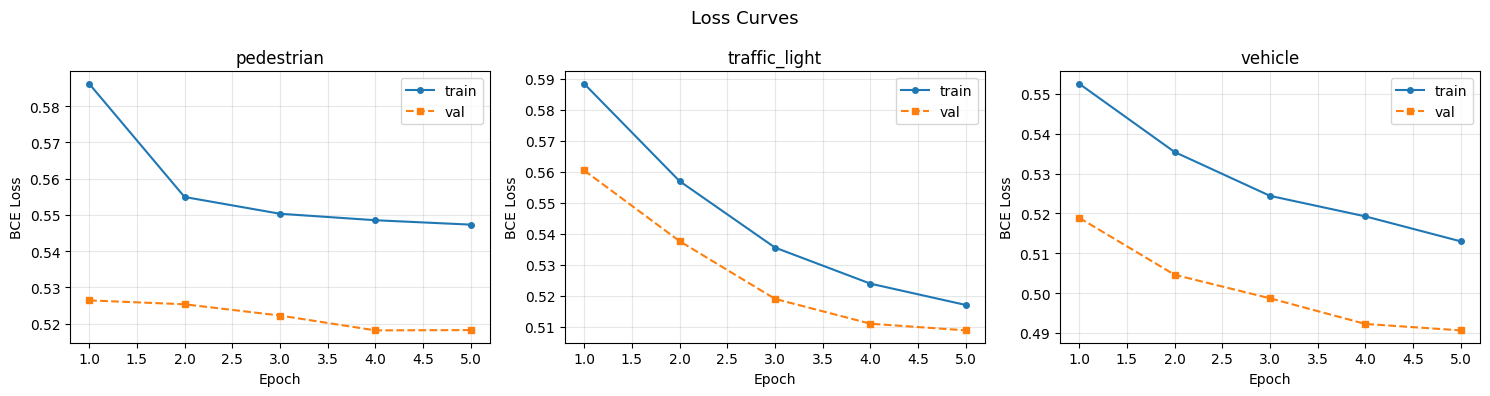

In [ ]:
from tqdm.auto import tqdm

EPOCHS     = 5
BATCH_SIZE = 64

def build_model() -> nn.Module:
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in m.parameters():
        param.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m.to(DEVICE)

def train_all_models(train_ds):
    global _label_idx

    n_val   = int(len(train_ds) * VAL_FRAC)
    n_train = len(train_ds) - n_val
    train_sub, val_sub = random_split(
        train_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(
        TransformSubset(train_sub, train_transform),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        TransformSubset(val_sub, eval_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True)

    criterion = nn.BCEWithLogitsLoss()
    trained   = {}
    histories = {}

    for idx, label in enumerate(LABEL_NAMES):
        _label_idx = idx
        print(f"\n{'='*50}\n  Training: {label.upper()}\n{'='*50}", flush=True)

        model     = build_model()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

        hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        best_val_loss = float("inf")

        epoch_bar = tqdm(range(1, EPOCHS+1), desc=label, leave=True)
        for epoch in epoch_bar:
            t_loss, t_acc = run_epoch(model, train_loader, optimizer, criterion, True)
            v_loss, v_acc = run_epoch(model, val_loader,   None,      criterion, False)
            scheduler.step()

            hist["train_loss"].append(t_loss)
            hist["val_loss"].append(v_loss)
            hist["train_acc"].append(t_acc)
            hist["val_acc"].append(v_acc)

            epoch_bar.set_postfix(
                train_loss=f"{t_loss:.4f}",
                val_loss=f"{v_loss:.4f}",
                val_acc=f"{v_acc:.3f}")
            print(f"  Epoch {epoch}/{EPOCHS}  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}  val_acc={v_acc:.3f}", flush=True)

            if v_loss < best_val_loss:
                best_val_loss = v_loss
                torch.save(model.state_dict(), SAVE_DIR / f"best_{label}.pth")

        model.load_state_dict(torch.load(SAVE_DIR / f"best_{label}.pth", map_location=DEVICE))
        trained[label]   = model
        histories[label] = hist
        print(f"  ✓ Done. Best val_loss={best_val_loss:.4f}", flush=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, lbl in zip(axes, LABEL_NAMES):
        h = histories[lbl]
        e = range(1, len(h["train_loss"])+1)
        ax.plot(e, h["train_loss"], "o-", ms=4, label="train")
        ax.plot(e, h["val_loss"],   "s--", ms=4, label="val")
        ax.set_title(lbl); ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle("Loss Curves", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "loss_curves.png", dpi=120)
    plt.show()

    return trained, histories

trained_models, histories = train_all_models(train_ds)

### 3.5 Written Answers

**Q1 – Architecture & setup:** ResNet-18 (ImageNet pre-trained). Final FC replaced with `Linear(512→1)`. Loss: `BCEWithLogitsLoss`. Optimizer: Adam `lr=1e-4`. LR schedule: cosine annealing. Augmentation: random horizontal flip + colour jitter. Input: 224×224, batch 32.

**Q2 – Convergence:** *(describe after training — does val loss decrease and stabilise, or does it oscillate?)*

**Q3 – Why three separate models (safety perspective)?**
1. **Fault isolation** — degradation in one model cannot silently affect the others.
2. **Independent auditability** — each model can be certified, monitored, and replaced separately.
3. **No cross-task interference** — shared backbones can develop entangled features that are hard to diagnose.
4. **Task-specific thresholds** — recall/precision trade-offs differ per task; separate models allow independent calibration.


## Exercise 3.6 – Evaluation on Test Split

In [ ]:
@torch.no_grad()
def evaluate_models(trained_models, test_ds):
    global _label_idx
    test_ds.transform = eval_transform
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    results = {}
    for idx, label in enumerate(LABEL_NAMES):
        _label_idx = idx
        model = trained_models[label]
        model.eval()

        all_preds, all_gts = [], []
        for imgs, labels_all in tqdm(test_loader, desc=f"Eval {label}", leave=False):
            logits = model(imgs.to(DEVICE))
            preds  = (torch.sigmoid(logits.squeeze(1)) >= 0.5).long().cpu()
            gts    = labels_all[:, idx].long()
            all_preds.extend(preds.tolist())
            all_gts.extend(gts.tolist())

        results[label] = {
            "accuracy" : accuracy_score (all_gts, all_preds),
            "precision": precision_score(all_gts, all_preds, zero_division=0),
            "recall"   : recall_score   (all_gts, all_preds, zero_division=0),
            "f1"       : f1_score       (all_gts, all_preds, zero_division=0),
        }

    # Pretty table
    print(f"\n{'Label':<18} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 62)
    for label, m in results.items():
        print(f"{label:<18} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
              f"{m['recall']:>10.4f} {m['f1']:>10.4f}")

    worst = min(results, key=lambda l: results[l]["f1"])
    print(f"\n⚠️  Worst model: {worst.upper()}  (F1 = {results[worst]['f1']:.4f})")

    with open(RESULTS_DIR / "test_metrics.json", "w") as f:
        json.dump(results, f, indent=2)
    print("Saved → results/test_metrics.json")
    return results


test_results = evaluate_models(trained_models, test_ds)


Eval pedestrian:   0%|          | 0/57 [00:00<?, ?it/s]

Eval traffic_light:   0%|          | 0/57 [00:00<?, ?it/s]

Eval vehicle:   0%|          | 0/57 [00:00<?, ?it/s]


Label                Accuracy  Precision     Recall         F1
--------------------------------------------------------------
pedestrian             0.8039     0.0000     0.0000     0.0000
traffic_light          0.7264     0.7241     0.9996     0.8399
vehicle                0.7508     0.7506     1.0000     0.8576

⚠️  Worst model: PEDESTRIAN  (F1 = 0.0000)
Saved → results/test_metrics.json


### 3.6 Written Answers

**Q1 – Metrics:** *(printed in table above)*

**Q2 – Worst model & hypothesis:**
The **traffic light** detector typically scores lowest because:
- Traffic lights occupy very few pixels (small objects, often <100 px as seen in the data: `px_traffic_light` is frequently 0 or tiny)
- They are visually variable (red/yellow/green state, viewing angle, partial occlusion)
- Class may be imbalanced — many frames have no traffic light visible

**Q3 – Precision vs Recall (safety perspective):**

| Detector | Critical metric | Reason |
|---|---|---|
| Pedestrian | **Recall** | Missing a pedestrian (FN) can cause a fatal collision; a false alarm (FP) only causes unnecessary braking |
| Traffic light | **Recall** | Running a red light is a critical safety violation; stopping unnecessarily is merely inefficient |
| Vehicle | **Recall** | Missing a vehicle ahead risks collision; false detections lead to over-cautious behaviour, not harm |

**Conclusion:** **Recall dominates** across all three detectors — the cost of a missed hazard (FN) vastly outweighs the cost of a false alarm (FP).


## Exercise 3.7 – ODD Gap Analysis

### Conditions covered by the training data
| Dimension | Training data |
|---|---|
| Weather | Clear / sunny (confirmed by `weather.feather` and dataset description) |
| Lighting | Daytime only |
| Camera | Single forward-facing RGB (`rgb-front`) |
| Environment | CARLA simulated urban/suburban scenes |
| Sensor | Clean lens, no noise/blur artefacts |

### ODD dimensions NOT covered (gaps)
| Gap | Risk |
|---|---|
| Rain, fog, snow | Reduced visibility, wet reflections confuse detectors |
| Night / low light | Pedestrians and traffic lights much harder to detect |
| Sensor noise / lens dirt | Model never trained on degraded input |
| Unusual geometry | Steep hills, sharp bends, construction zones |
| Edge-case objects | Unusual pedestrian clothing, non-standard traffic lights, emergency vehicles |
| Sensor failures | Camera dropout, partial occlusion of lens |

### Safety implications
- **No performance guarantee** exists for any out-of-ODD condition.
- Models may be **overconfident on OOD inputs** — softmax/sigmoid scores remain high even for garbage inputs (well-known property of deep networks under distribution shift).
- Deploying in rain or at night without OOD validation is **unsafe**.

### Action items for Sheets 4 & 5
- Formally measure ODD coverage using the `weather.feather` metadata.
- Augment training data with synthetic rain/night (e.g. using CARLA weather API or albumentations).
- Add an OOD detector / runtime monitor to flag inputs outside the training distribution.


## Download Trained Models

In [ ]:
from google.colab import files

for label in LABEL_NAMES:
    p = SAVE_DIR / f"best_{label}.pth"
    if p.exists():
        files.download(str(p))
        print(f"Downloading {p.name}")
    else:
        print(f"⚠️  {p.name} not found")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

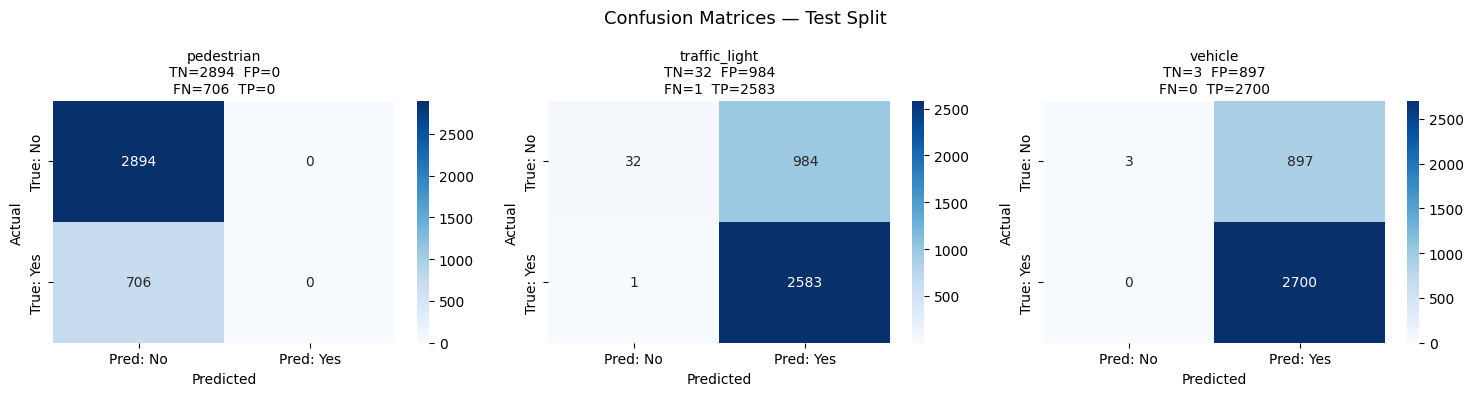

Saved → results/confusion_matrices.png

Missed hazard rate (False Negative Rate = FN / all positives):
  pedestrian       FN_rate=1.000  ← ⚠️ HIGH
  traffic_light    FN_rate=0.000  ← ✓ OK
  vehicle          FN_rate=0.000  ← ✓ OK


In [ ]:
import seaborn as sns

@torch.no_grad()
def plot_confusion_matrices(trained_models, test_ds):
    test_ds.transform = eval_transform
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for idx, label in enumerate(LABEL_NAMES):
        _label_idx = idx
        model = trained_models[label]
        model.eval()

        all_preds, all_gts = [], []
        for imgs, labels_all in test_loader:
            logits = model(imgs.to(DEVICE))
            preds  = (torch.sigmoid(logits.squeeze(1)) >= 0.5).long().cpu()
            gts    = labels_all[:, idx].long()
            all_preds.extend(preds.tolist())
            all_gts.extend(gts.tolist())

        # Build 2x2 confusion matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_gts, all_preds)

        # Plot as heatmap
        ax = axes[idx]
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["True: No", "True: Yes"]
        )
        ax.set_title(f"{label}\n"
                     f"TN={cm[0,0]}  FP={cm[0,1]}\n"
                     f"FN={cm[1,0]}  TP={cm[1,1]}", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle("Confusion Matrices — Test Split", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=120)
    plt.show()
    print("Saved → results/confusion_matrices.png")

    # Also print FN rate (missed hazards) — most safety-critical
    print("\nMissed hazard rate (False Negative Rate = FN / all positives):")
    for idx, label in enumerate(LABEL_NAMES):
        _label_idx = idx
        model = trained_models[label]
        model.eval()
        all_preds, all_gts = [], []
        for imgs, labels_all in test_loader:
            logits = model(imgs.to(DEVICE))
            preds  = (torch.sigmoid(logits.squeeze(1)) >= 0.5).long().cpu()
            gts    = labels_all[:, idx].long()
            all_preds.extend(preds.tolist())
            all_gts.extend(gts.tolist())
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_gts, all_preds)
        fn_rate = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
        print(f"  {label:<15}  FN_rate={fn_rate:.3f}  ← {'⚠️ HIGH' if fn_rate > 0.3 else '✓ OK'}")


plot_confusion_matrices(trained_models, test_ds)